# COMP13212 Data Science.
# Lab 2. Uncertainty Estimation.

## Part 1: Data Sampling
The goal of the following exercises is to apply “Random Sampling” and “Sampling with Replacement” on the
Global Life Expectancy dataset to observe how these two methods impact the analysis. You will compare
the results using descriptive statistics and visualize how the sampling methods affect the data distributions.
The Gapminder dataset contains data on life expectancy, GDP per capita, number of residents, and
continents for various countries over the years 1950 to 2019. You will work with a subset of this dataset,
which involves performing sampling on it and then you will analyze the impact of various sampling methods.
This dataset has 1,704 rows (representing country-year combinations) and 6 columns, that includes entries
on:


*   **country**: The country name.
*   **year**: The year of the data entry.
*   **residents**: The number of residents in the country that year.
*   **continent**: The continent of the country.
*   **life_exp**: Life expectancy in that year.
*   **gdp_cap**: GDP per capita of the country.

### Exercise 1. Import the Global Life Expectancy Dataset
□ Load the dataset into a dataframe by replacing the path placeholder with the location of the downloaded Gapminder dataset.<br>
□ Display the first 5 rows of the dataset to examine its structure.
□ Print the .shape of the dataset to understand how many rows and columns it contains.<br>
□ Use the isnull() function to identify missing values in the dataset, and then apply the sum() function to calculate the total number of missing values in each column.<br>
□ Drop rows with missing values, you can use the dropna() function.<br>
□ Check for missing values again. <br>



                                                          [2 marks]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
# used print statements as it does not output on my laptop otherwise

In [3]:
# load dataset
df_preprocessed = pd.read_csv("gapminder_dataset.csv")

# display first 5 rows of dataset
print(df_preprocessed.head())

# print shape of dataset
print("\nShape:", df_preprocessed.shape)

# use isnull() and sum() total
print("\nTotal empty values per col: \n", df_preprocessed.isnull().sum())

# dropna()
df = df_preprocessed.dropna()

# missing value check
print("\nTotal empty values per col: \n", df.isnull().sum())


       country    year   residents continent  life_exp     gdp_cap
0  Afghanistan  1952.0   8425333.0      Asia    28.801  779.445314
1  Afghanistan  1957.0   9240934.0      Asia    30.332  820.853030
2  Afghanistan  1962.0  10267083.0      Asia    31.997  853.100710
3  Afghanistan  1967.0  11537966.0      Asia    34.020  836.197138
4  Afghanistan  1972.0  13079460.0      Asia    36.088  739.981106

Shape: (1704, 6)

Total empty values per col: 
 country      1
year         7
residents    2
continent    1
life_exp     3
gdp_cap      5
dtype: int64

Total empty values per col: 
 country      0
year         0
residents    0
continent    0
life_exp     0
gdp_cap      0
dtype: int64


### Exercise 2. Random Sampling
In this exercise, you will perform random sampling, a process where data points are selected independently,
meaning the selection of one data point does not influence the selection of another. Each data point in the
dataset has an equal probability of being chosen, ensuring fairness and randomness in the selection process.
Random sampling is commonly used to create representative subsets of a entire dataset, and it helps to
reduce bias in data analysis.<br>
□ Perform random sampling to select 10% of the dataset.
Use sample() method from pandas to randomly sample elements from your dataset, which in this case
is a entire dataset.
To ensure reproducibility of your results, you will use the random_state parameter. Setting the
random_state to a fixed integer value, such as 1 or 42, ensures that the sampling process produces
the same results each time the code is run.<br>
□ Display basic statistics for numerical values in the sample (like mean, standard deviation, min, max, etc.)<br>
□ Show the total number of data entries in the sample.<br>



                                                          [2 marks]

In [18]:
df["year"] = df["year"].astype(int)
df["residents"] = df["residents"].astype(int)

# randomly select 10% of the dataset with random_state
sample_df = df.sample(frac=0.1, random_state=42)

print(sample_df.describe(), "\n")

# total of data entries in sample
print(sample_df.shape[0], "entries (records) in sample")
print(sample_df.shape[0]*sample_df.shape[1], "entries (data points) in sample")


              year     residents    life_exp       gdp_cap
count   168.000000  1.680000e+02  168.000000    168.000000
mean   1980.869048  2.156379e+07   59.679958   8037.991814
std      17.082946  7.244811e+07   13.078036  11297.630882
min    1952.000000  6.001100e+04   33.489000    347.000000
25%    1967.000000  2.537198e+06   48.721750   1246.295553
50%    1982.000000  6.394268e+06   59.992500   4433.695004
75%    1997.000000  1.718260e+07   71.457500  10166.285412
max    2007.000000  8.620300e+08   81.235000  95458.111760 

168 entries (records) in sample
1008 entries (data points) in sample


C:\Users\siona\AppData\Local\Temp\ipykernel_32180\932430800.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["year"] = df["year"].astype(int)
C:\Users\siona\AppData\Local\Temp\ipykernel_32180\932430800.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["residents"] = df["residents"].astype(int)


### Exercise 3. Sampling with Replacement
In this exercise, you will perform sampling with replacement, meaning that the same row may be selected
multiple times. When sampling with replacement, after an element is selected from the dataset, it is re-
turned to the entire dataset, allowing it to be chosen again. Sampling with replacement is principle behind
“bootstrapping”.
□ Use panda’s sample() method for sampling with replacement to select 10% of the dataset. To perform this type of sampling, make sure to adjust the replace parameter.<br>
□ Display basic statistics for numerical values in the sample (like mean, standard deviation, min, max, etc.)<br>
□ Show the total number of data entries in this sample <br>



                                                          [2 marks]

In [19]:
# sampling 10% of df w/ replacement
sample_rep_df = df.sample(frac=0.1, replace=True, random_state=42)

# statistics and number of entries
print(sample_rep_df.describe(), "\n")

print(sample_rep_df.shape[0], "entries (records) in sample")
print(sample_rep_df.shape[0]*sample_rep_df.shape[1], "entries (data points) in sample")

              year     residents    life_exp        gdp_cap
count   168.000000  1.680000e+02  168.000000     168.000000
mean   1979.232143  3.596581e+07   60.456763    8212.038374
std      17.558789  1.243779e+08   12.675707   12059.970162
min    1952.000000  8.989800e+04   32.500000     298.846212
25%    1965.750000  2.795314e+06   49.502750    1287.610862
50%    1977.000000  7.403310e+06   62.115000    3516.196408
75%    1997.000000  2.053276e+07   71.660500   10712.713518
max    2007.000000  1.280400e+09   81.757000  109347.867000 

168 entries (records) in sample
1008 entries (data points) in sample


### Exercise 4. Visual Comparison of Random Sample vs. Sample with Replacement
□ Create a visual comparison of the life expectancy (life_exp) distributions between the random sample
and the sample with replacement by plotting the histograms of both distributions, using hist method
from matplotlib.pyplot.
You can observe how the two sampling methods influence the data distribution.


                                                          [2 marks]

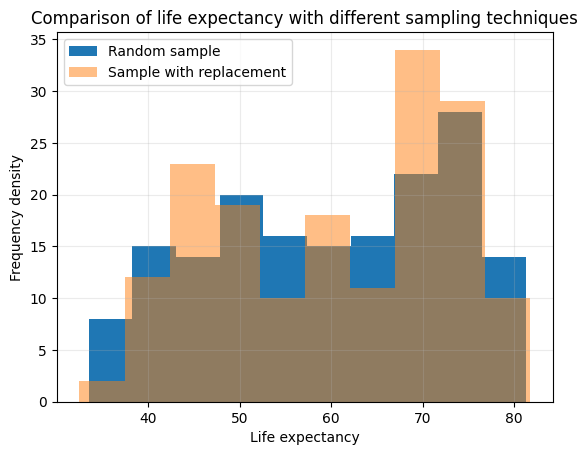

In [20]:
# histograms of sample and sample_rep
plt.hist(sample_df["life_exp"],
         label="Random sample")
plt.hist(sample_rep_df["life_exp"],
         alpha=0.5,
         label="Sample with replacement")

plt.title("Comparison of life expectancy with different sampling techniques")
plt.xlabel("Life expectancy")
plt.ylabel("Frequency density")
plt.grid(True, alpha=0.25)
plt.legend()

plt.show()

### Exercise 5. Compare the Mean Life Expectancy for Each Sampling Method
□ Compute the mean of life expectancy (life_exp) for both the random sample and the sample with replacement. <br>
□ Compare the results by printing, to observe the impact of the sampling methods on central tendencies. <br>


                                                          [2 marks]

In [22]:
mean_sample = sample_df["life_exp"].mean()
mean_sample_rep = sample_rep_df["life_exp"].mean()

print("Mean of random sample:", mean_sample)
print("Mean of random sample (2dp):", mean_sample.round(2), "\n")
print("Mean of sample with replacement:", mean_sample_rep)
print("Mean of sample with replacement (2dp):", mean_sample_rep.round(2))

Mean of random sample: 59.67995761904761
Mean of random sample (2dp): 59.68 

Mean of sample with replacement: 60.456762619047616
Mean of sample with replacement (2dp): 60.46


## Part 2: Uncertainty Estimation
In the following exercises, you will calculate the standard error in the mean (SEM) and confidence intervals for the life expectancy (life_exp) using both the random sample and sample with replacement. This helps you understand how the precision of the mean estimate changes with different sampling methods.
Additionally, you will compare sample estimates to population values to see how well the sample approximates the population as sample size increases.


### Exercise 6: Calculate the Standard Error in the Mean (SEM) for Random Sample
□ Calculate the standard error in the mean (SEM) of life expectancy (life_exp) for the random sample.
The SEM quantifies the uncertainty around the sample mean, and computed using the formula:
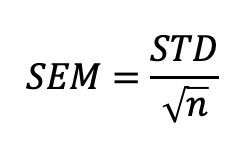
, where STD is standard deviation, and n is sample size.


                                                          [2 marks]


In [8]:
# SEM method: print(sample_df["life_exp"].sem())
# Calculation:
sem_sample = sample_df["life_exp"].std() / sample_df["life_exp"].count()**(1/2)
print("SEM of random sample:", sem_sample)
print("SEM of random sample (3dp):", sem_sample.round(3))

SEM of random sample: 1.0089924143243005
SEM of random sample (3dp): 1.009


### Exercise 7: Calculate the Confidence Interval for Random Sample
□ Estimate the 95% confidence interval for the mean of life expectancy (life_exp) from the random sample using the stats.t.interval function, specifying the confidence level, degrees of freedom df, sample mean, and SEM. <br>
The degrees of freedom (df) refers to the number of independent values or observations that are free to vary when estimating a parameter. Degrees of freedom: df=n−1. <br>


                                                          [2 marks]


In [9]:
ci_sample = stats.t.interval(0.95,
                              df=sample_df["life_exp"].count()-1,
                              loc=mean_sample,
                              scale=sem_sample)

print("95% CI for mean of life expectancy in random sample:", ci_sample[0], "to", ci_sample[1])
print("95% CI for mean of life expectancy in random sample (3dp):", ci_sample[0].round(3), "to", ci_sample[1].round(3))

95% CI for mean of life expectancy in random sample: 57.687975580537916 to 61.67202441946208
95% CI for mean of life expectancy in random sample (3dp): 57.688 to 61.672


### Exercise 8. Confidence Interval (Sample with Replacement)
□ Repeat the process of calculating the SEM and confidence interval for the sample with replacement. <br>


                                                          [2 marks]



In [23]:
# SEM method: print(sample_rep_df["life_exp"].sem())
# Calculation:
sem_sample_rep = sample_rep_df["life_exp"].std() / sample_rep_df["life_exp"].count()**(1/2)
print("SEM of sample with replacement:", sem_sample_rep)
print("SEM of sample with replacement (3dp):", sem_sample_rep.round(3), "\n")

ci_sample_rep = stats.t.interval(0.95,
                              df=sample_rep_df["life_exp"].count()-1,
                              loc=mean_sample_rep,
                              scale=sem_sample_rep)

print("95% CI for mean of life expectancy in sample with replacement:", ci_sample_rep[0], "to", ci_sample_rep[1])
print("95% CI for mean of life expectancy in sample with replacement (3dp):", ci_sample_rep[0].round(3), "to", ci_sample_rep[1].round(3))

SEM of sample with replacement: 0.977952025100657
SEM of sample with replacement (3dp): 0.978 

95% CI for mean of life expectancy in sample with replacement: 58.52602033852462 to 62.387504899570615
95% CI for mean of life expectancy in sample with replacement (3dp): 58.526 to 62.388


### Exercise 9. Plot SEM as Error Bars
In this exercise, you will visualize the SEM as error bars for both the random sample and the sample with replacement. This helps you visualize the uncertainty around the mean of life expectancy (life_exp) estimates based on different sampling methods.<br>
□ Plot the means for both the random sample and the sample with replacement, with SEM represented as error bars.<br>
Use the errorbar() function from matplotlib.pyplot to create a plot with error bars, where the error bars represent the SEM.


                                                          [2 marks]


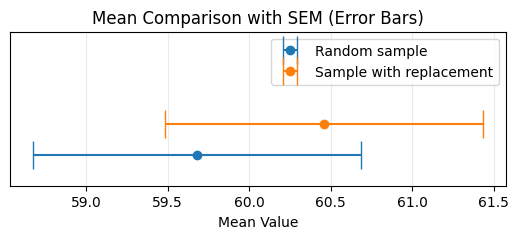

In [11]:
"""plt.errorbar(sample_df["life_exp"], 
             sample_rep_df["life_exp"],
             xerr=sem_sample,
             yerr=sem_sample_rep)

plt.show()"""

plt.figure(figsize=(6.4, 2))
plt.errorbar(
    mean_sample, 0.1, xerr=sem_sample, fmt='o', capsize=10, label="Random sample"
)
plt.errorbar(
    mean_sample_rep, 0.2, xerr=sem_sample_rep, fmt='o', capsize=10, label="Sample with replacement"
)

plt.gca().yaxis.set_visible(False)  
plt.ylim(0, 0.5)

plt.legend()
plt.xlabel("Mean Value")
plt.title("Mean Comparison with SEM (Error Bars)")
plt.grid(True, alpha=0.25)

plt.show()

### Exercise 10. Visualizing Sample and Population Values
In this exercise, you’ll explore how the sample mean and confidence intervals behave with different sample
sizes, comparing them to the mean and standard deviation of the entire dataset.
Note: For this exercise, you can use either random sampling or sampling with replacement. Continue working
with the life expectancy (life_exp) column. Note that in this context, the entire dataset refers to the raw pre-processed dataset.<br>
□ Choose any sampling method (e.g., random sampling or sampling with replacement).<br>
□ Work with 10%, 20%, 30%, 40%, 50%, and 100% of the dataset.<br>
□ Calculate the entire mean and entire standard deviation from the entire pre-processed dataset.<br>
□ Compute the sample mean and SEM for each sample size.<br>
□ Calculate the sample standard deviation. Estimate the 95% confidence interval for the sample mean.<br>
□ Plot sample means (as dots) and confidence intervals (as error bars). Include the entire mean and
entire standard deviation (as dashed lines).<br>
□ Plot SEM and sample standard deviation.<br>


                                                          [2 marks]


For entire pre-processed dataset:
Mean: 59.49106741916519
STD: 12.913685189922854

For 10% random sample:
Mean: 59.70447576470588
SEM: 0.9670067514729003
STD: 12.571087769147677
CI: 57.7955073039854 to 61.61344422542636

For 20% random sample:
Mean: 59.485254780058646
SEM: 0.7196753423606538
STD: 13.27015762742307
CI: 58.06967804196626 to 60.90083151815103

For 30% random sample:
Mean: 59.842805949119374
SEM: 0.5825151262510898
STD: 13.155043704935926
CI: 58.698381372538776 to 60.98723052569997

For 40% random sample:
Mean: 59.98182087976539
SEM: 0.5027116674689888
STD: 13.118751961792613
CI: 58.994769851489465 to 60.96887190804131

For 50% random sample:
Mean: 59.73880004700353
SEM: 0.4481107414921219
STD: 13.06456088602008
CI: 58.859266744597065 to 60.618333349409994



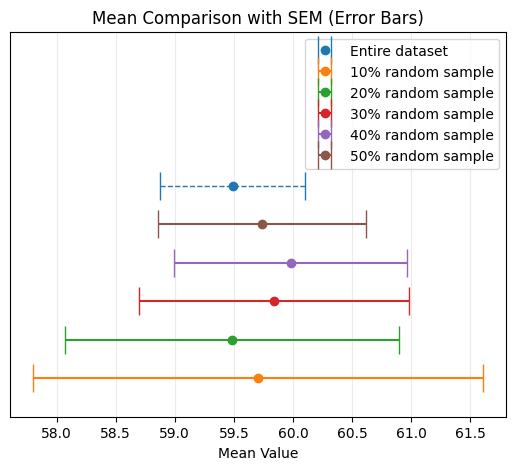

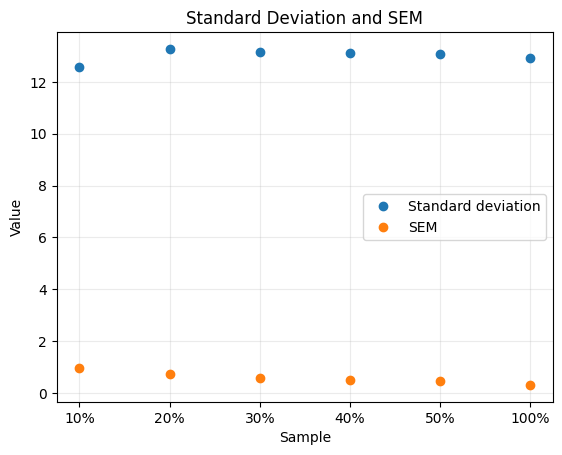

In [17]:
sample1_df = df_preprocessed.sample(frac=0.1, random_state=1)
sample2_df = df_preprocessed.sample(frac=0.2, random_state=1)
sample3_df = df_preprocessed.sample(frac=0.3, random_state=1)
sample4_df = df_preprocessed.sample(frac=0.4, random_state=1)
sample5_df = df_preprocessed.sample(frac=0.5, random_state=1)
sample_entire_df = df_preprocessed
sample_list = [sample1_df,sample2_df,sample3_df,sample4_df,sample5_df]
stds=[]
sems=[]

# calculate mean and std for whole dataset
mean = sample_entire_df["life_exp"].sum() / sample_entire_df["life_exp"].count()
square_mean = sample_entire_df["life_exp"].apply(lambda x:x**2).mean()
std = (square_mean - mean**2)**0.5
stds.append(std)
sems.append(sample_entire_df["life_exp"].sem())
print("For entire pre-processed dataset:")
print("Mean:", mean)
print("STD:", std)
print()

ci = stats.t.interval(0.95,
                    df=sample_entire_df["life_exp"].count()-1,
                    loc=mean,
                    scale=sample_entire_df["life_exp"].sem())
ci_bar = ci[1]-mean

# plot dashed lines for entire dataset on single subplot
fig, ax1 = plt.subplots(figsize=(6.4, 5))
ax1.grid(True, alpha=0.25)
fig, ax2 = plt.subplots()
ax2.grid(True, alpha=0.25)

ax1.errorbar(
    mean, 6, xerr=ci_bar, fmt='o', capsize=10, 
    elinewidth=0, label="Entire dataset"
)
ax1.plot([mean - ci_bar, mean + ci_bar], 
         [6, 6], 'C0--', linewidth=1)

#sem and std of 

# values of samples
for i in range(5):
    print(f"For {(i+1)*10}% random sample:")
    sample = sample_list[i]
    # computed mean and sem
    mean = sample["life_exp"].mean()
    sem = sample["life_exp"].sem()
    # calculated std
    square_mean = sample["life_exp"].apply(lambda x:x**2).mean()
    std = (square_mean - mean**2)**0.5
    # estimated ci
    ci = stats.t.interval(0.95,
                    df=sample["life_exp"].count()-1,
                    loc=mean,
                    scale=sem)

    print("Mean:", mean)
    print("SEM:", sem)
    print("STD:", std)
    print("CI:", ci[0], "to", ci[1])
    print()

    stds.append(std)
    sems.append(sem)

    # plot mean and ci for samples
    ci_bar = ci[1]-mean
    ax1.errorbar(
        mean, i+1, xerr=ci_bar, fmt='o', capsize=10, label=f"{(i+1)*10}% random sample"
    )

# plot sem and std
stds.append(stds.pop(0))
sems.append(sems.pop(0))
samples=["10%","20%","30%","40%","50%","100%"]
ax2.plot(samples, stds, "o", label="Standard deviation")
ax2.plot(samples, sems, "o", label="SEM")

ax1.yaxis.set_visible(False)  
ax1.set_ylim(0, 10)
ax1.legend()
ax1.set_title("Mean Comparison with SEM (Error Bars)")
ax1.set_xlabel("Mean Value")

ax2.legend()
ax2.set_title("Standard Deviation and SEM")
ax2.set_ylabel("Value")
ax2.set_xlabel("Sample")

plt.show()

### Optional. Analysis of the results
◦ How does the sample mean change with increasing sample size?
<br>
As we increase the sample size of the dataset, the sample mean starts getting closer to the population mean. Hence, with a bigger sample size, our estimate of population mean becomes more accurate. <br>
◦ How does the SEM behave as sample size increases?
<br>
The SEM reduces as sample size increases, because even in the sample error mean formula, SEM is inversely proportional to root of sample size.
<br>
◦ What happens to the confidence intervals with larger sample sizes?
<br>
The confidence intervals with larger sample sizes have a smaller confidence interval range(which means the margin of error decreases), hence it is a more precise estimate of population mean.
<br>
◦ What sample size is sufficient for a reliable estimate of the population mean?
<br>
A sample size around 40% gives a sample mean that is relatively close to the population mean.
<br>
◦ At what sample size does the SEM stabilize?
<br>
The SEM stabilizes when sample size is around 40%, the decrease in SEM from 40% to 50% is very less, hence we can say SEM stabiizes around this range.
<br>